# Stage 01 — UCI Statlog German Credit Data Exploration

This notebook establishes the factual characteristics, provenance, schema, target semantics, data quality, and limitations of Dataset 2 before any modelling decisions are made.

**Scope guard:** exploration only. No row removal, imputation, encoding, scaling, feature selection, train/test split, preprocessing fit, or model training is performed.


## 1. Reproducible setup and isolated paths

The notebook uses the official UCI retrieval client for first acquisition and then prefers the preserved local raw snapshot. All Dataset 2 outputs are isolated from the frozen Home Credit artifacts.


In [1]:
from datetime import datetime, timezone
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from ucimlrepo import fetch_ucirepo

UCI_DATASET_ID = 144
DATASET_NAME = "Statlog (German Credit Data)"
TARGET = "class"
EXPECTED_ROWS = 1000
EXPECTED_FEATURES = 20
EXPECTED_TARGET_VALUES = {1, 2}
RANDOM_STATE = 42  # Recorded for consistency; no randomness is used in Stage 01.

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "german_credit":
    candidate = NOTEBOOK_DIR / "backend" / "ml" / "german_credit"
    if candidate.exists():
        NOTEBOOK_DIR = candidate
    else:
        raise RuntimeError("Run this notebook from backend/ml/german_credit or the project root.")
BACKEND_DIR = NOTEBOOK_DIR.parents[1]
RAW_DIR = BACKEND_DIR / "data" / "german_credit" / "raw"
ARTIFACTS_DIR = BACKEND_DIR / "artifacts" / "german_credit"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
RAW_SNAPSHOT_PATH = RAW_DIR / "german_credit_raw.csv"
VARIABLES_SNAPSHOT_PATH = RAW_DIR / "german_credit_variables.csv"
PROVENANCE_PATH = ARTIFACTS_DIR / "dataset_provenance.json"

for directory in (RAW_DIR, ARTIFACTS_DIR, PLOTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Raw snapshot: {RAW_SNAPSHOT_PATH}")
print(f"Dataset 2 artifacts: {ARTIFACTS_DIR}")


Notebook directory: c:\Users\H P E L I T E\Desktop\XAI_CreditStudy\backend\ml\german_credit
Raw snapshot: c:\Users\H P E L I T E\Desktop\XAI_CreditStudy\backend\data\german_credit\raw\german_credit_raw.csv
Dataset 2 artifacts: c:\Users\H P E L I T E\Desktop\XAI_CreditStudy\backend\artifacts\german_credit


## 2. Official acquisition with local-snapshot fallback

On first execution, the notebook retrieves UCI dataset ID 144 using `fetch_ucirepo` and writes a raw CSV snapshot plus the UCI variable table. Existing raw snapshots are never overwritten. Subsequent executions load the snapshot without requiring network access.


In [2]:
retrieved_from_uci = False
if RAW_SNAPSHOT_PATH.exists() and VARIABLES_SNAPSHOT_PATH.exists() and PROVENANCE_PATH.exists():
    raw_df = pd.read_csv(RAW_SNAPSHOT_PATH)
    variables = pd.read_csv(VARIABLES_SNAPSHOT_PATH)
    with PROVENANCE_PATH.open(encoding="utf-8") as file:
        provenance = json.load(file)
    acquisition_mode = "local raw snapshot"
else:
    dataset = fetch_ucirepo(id=UCI_DATASET_ID)
    X = dataset.data.features.copy()
    y_frame = dataset.data.targets.copy()
    if isinstance(y_frame, pd.Series):
        y_frame = y_frame.to_frame(name=TARGET)
    raw_df = pd.concat([X.reset_index(drop=True), y_frame.reset_index(drop=True)], axis=1)
    variables = dataset.variables.copy()
    retrieved_at = datetime.now(timezone.utc).isoformat()
    provenance = {
        "dataset_name": DATASET_NAME,
        "uci_dataset_id": UCI_DATASET_ID,
        "repository_url": dataset.metadata.get("repository_url"),
        "data_url": dataset.metadata.get("data_url"),
        "dataset_doi": dataset.metadata.get("dataset_doi"),
        "retrieval_method": "ucimlrepo.fetch_ucirepo(id=144)",
        "retrieved_at_utc": retrieved_at,
        "raw_observations": int(len(X)),
        "raw_predictors": int(X.shape[1]),
        "target_column": TARGET,
        "target_encoding": {"1": "Good credit risk", "2": "Bad credit risk / higher-risk class"},
        "raw_snapshot": str(RAW_SNAPSHOT_PATH.relative_to(BACKEND_DIR)),
        "variables_snapshot": str(VARIABLES_SNAPSHOT_PATH.relative_to(BACKEND_DIR)),
    }
    raw_df.to_csv(RAW_SNAPSHOT_PATH, index=False)
    variables.to_csv(VARIABLES_SNAPSHOT_PATH, index=False)
    with PROVENANCE_PATH.open("w", encoding="utf-8") as file:
        json.dump(provenance, file, indent=2)
    retrieved_from_uci = True
    acquisition_mode = "official UCI retrieval; new local snapshot persisted"

feature_names = [name for name in raw_df.columns if name != TARGET]
X = raw_df[feature_names].copy()
y = raw_df[TARGET].copy()

print(f"Acquisition mode: {acquisition_mode}")
print(f"Dataset: {provenance['dataset_name']} (UCI ID {provenance['uci_dataset_id']})")
print(f"Raw snapshot modified during this run: {retrieved_from_uci}")
display(pd.DataFrame([provenance]))


Acquisition mode: local raw snapshot
Dataset: Statlog (German Credit Data) (UCI ID 144)
Raw snapshot modified during this run: False


,dataset_name,uci_dataset_id,repository_url,data_url,dataset_doi,retrieval_method,retrieved_at_utc,raw_observations,raw_predictors,target_column,target_encoding,raw_snapshot,variables_snapshot
0,Statlog (German Credit Data),144,https://archive.ics.uci.edu/dataset/144/statlo...,https://archive.ics.uci.edu/static/public/144/...,10.24432/C5NC77,ucimlrepo.fetch_ucirepo(id=144),2026-08-21T21:32:23.925205+00:00,1000,20,class,"{'1': 'Good credit risk', '2': 'Bad credit ris...",data\german_credit\raw\german_credit_raw.csv,data\german_credit\raw\german_credit_variables...


## 3. Shape, rows, and feature names


In [3]:
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nFirst five raw rows:")
display(raw_df.head())
print("\nFeature names:")
display(pd.Series(feature_names, name="feature_name").to_frame())


Feature matrix shape: (1000, 20)
Target shape: (1000,)

First five raw rows:


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2



Feature names:


,feature_name
0,Attribute1
1,Attribute2
2,Attribute3
3,Attribute4
4,Attribute5
5,Attribute6
6,Attribute7
7,Attribute8
8,Attribute9
9,Attribute10


## 4. Official variable definitions and target semantics

The UCI metadata defines the original target as `class`: **1 = Good** and **2 = Bad**. Value 2 is therefore the bad/higher-risk credit class. This notebook preserves the original 1/2 coding and does not create a modelling target.


In [4]:
display(variables)
target_definition = variables.loc[variables["name"].eq(TARGET)]
print("Official target definition:")
display(target_definition)
print(f"Observed target values: {sorted(y.dropna().unique().tolist())}")
print("Interpretation: 1 = Good credit risk; 2 = Bad credit risk / higher-risk class.")


,name,role,type,demographic,description,units,missing_values
0,Attribute1,Feature,Categorical,NaN,Status of existing checking account,NaN,no
1,Attribute2,Feature,Integer,NaN,Duration,months,no
2,Attribute3,Feature,Categorical,NaN,Credit history,NaN,no
3,Attribute4,Feature,Categorical,NaN,Purpose,NaN,no
4,Attribute5,Feature,Integer,NaN,Credit amount,NaN,no
5,Attribute6,Feature,Categorical,NaN,Savings account/bonds,NaN,no
6,Attribute7,Feature,Categorical,Other,Present employment since,NaN,no
7,Attribute8,Feature,Integer,NaN,Installment rate in percentage of disposable i...,NaN,no
8,Attribute9,Feature,Categorical,Marital Status,Personal status and sex,NaN,no
9,Attribute10,Feature,Categorical,NaN,Other debtors / guarantors,NaN,no


Official target definition:


,name,role,type,demographic,description,units,missing_values
20,class,Target,Binary,NaN,"1 = Good, 2 = Bad",NaN,no


Observed target values: [1, 2]
Interpretation: 1 = Good credit risk; 2 = Bad credit risk / higher-risk class.


## 5. Target class distribution


,target_value,meaning,count,percentage
0,1,Good credit risk,700,70.0
1,2,Bad credit risk / higher-risk,300,30.0


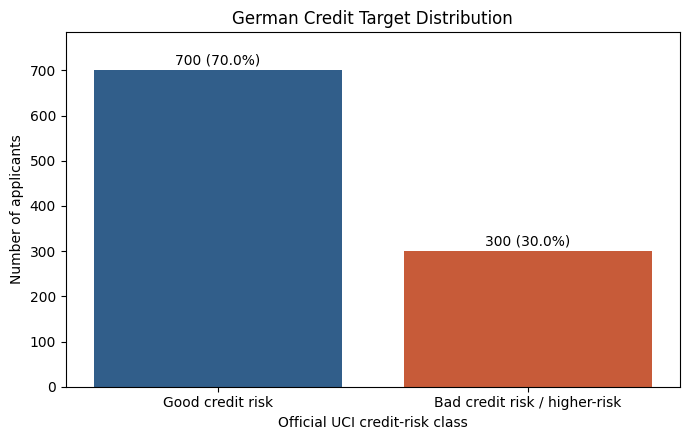

In [5]:
target_counts = y.value_counts(dropna=False).sort_index()
target_percentages = y.value_counts(normalize=True, dropna=False).sort_index().mul(100)
target_distribution = pd.DataFrame({
    "target_value": target_counts.index,
    "meaning": ["Good credit risk" if value == 1 else "Bad credit risk / higher-risk" for value in target_counts.index],
    "count": target_counts.values,
    "percentage": target_percentages.values,
})
display(target_distribution)

target_distribution.to_csv(ARTIFACTS_DIR / "target_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#315E8A", "#C75B39"]
ax.bar(target_distribution["meaning"], target_distribution["count"], color=colors)
ax.set_title("German Credit Target Distribution")
ax.set_xlabel("Official UCI credit-risk class")
ax.set_ylabel("Number of applicants")
ax.set_ylim(0, target_distribution["count"].max() * 1.12)
for position, row in target_distribution.iterrows():
    ax.text(position, row["count"] + 12, f"{row['count']} ({row['percentage']:.1f}%)", ha="center")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "german_credit_target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Data types and feature audit


In [6]:
variable_lookup = variables.set_index("name")
feature_audit = pd.DataFrame({
    "feature": feature_names,
    "pandas_dtype": X.dtypes.astype(str).reindex(feature_names).values,
    "uci_type": [variable_lookup.loc[name, "type"] for name in feature_names],
    "description": [variable_lookup.loc[name, "description"] for name in feature_names],
    "units": [variable_lookup.loc[name, "units"] for name in feature_names],
    "demographic": [variable_lookup.loc[name, "demographic"] for name in feature_names],
    "unique_values": X.nunique(dropna=False).reindex(feature_names).values,
})
numerical_features = feature_audit.loc[feature_audit["uci_type"].eq("Integer"), "feature"].tolist()
categorical_features = feature_audit.loc[feature_audit["uci_type"].isin(["Categorical", "Binary"]), "feature"].tolist()
feature_audit["analysis_group"] = np.where(feature_audit["feature"].isin(numerical_features), "numerical", "categorical")

display(feature_audit)
print(f"Numerical features: {len(numerical_features)} — {numerical_features}")
print(f"Categorical/binary features: {len(categorical_features)} — {categorical_features}")
feature_audit.to_csv(ARTIFACTS_DIR / "feature_audit.csv", index=False)


,feature,pandas_dtype,uci_type,description,units,demographic,unique_values,analysis_group
0,Attribute1,object,Categorical,Status of existing checking account,NaN,NaN,4,categorical
1,Attribute2,int64,Integer,Duration,months,NaN,33,numerical
2,Attribute3,object,Categorical,Credit history,NaN,NaN,5,categorical
3,Attribute4,object,Categorical,Purpose,NaN,NaN,10,categorical
4,Attribute5,int64,Integer,Credit amount,NaN,NaN,921,numerical
5,Attribute6,object,Categorical,Savings account/bonds,NaN,NaN,5,categorical
6,Attribute7,object,Categorical,Present employment since,NaN,Other,5,categorical
7,Attribute8,int64,Integer,Installment rate in percentage of disposable i...,NaN,NaN,4,numerical
8,Attribute9,object,Categorical,Personal status and sex,NaN,Marital Status,4,categorical
9,Attribute10,object,Categorical,Other debtors / guarantors,NaN,NaN,3,categorical


Numerical features: 7 — ['Attribute2', 'Attribute5', 'Attribute8', 'Attribute11', 'Attribute13', 'Attribute16', 'Attribute18']
Categorical/binary features: 13 — ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute9', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20']


## 7. Missing values and duplicate rows

Both native missing values and exact duplicate complete rows are quantified. Special categories such as “unknown/no account” are examined separately because they are substantive codes rather than pandas missing values.


In [7]:
missing_counts = raw_df.isna().sum()
missing_audit = pd.DataFrame({
    "column": raw_df.columns,
    "missing_count": missing_counts.reindex(raw_df.columns).values,
    "missing_percentage": missing_counts.reindex(raw_df.columns).div(len(raw_df)).mul(100).values,
})
duplicate_rows = int(raw_df.duplicated().sum())
duplicate_feature_rows = int(X.duplicated().sum())

display(missing_audit)
print(f"Exact duplicate complete rows (features + target): {duplicate_rows}")
print(f"Duplicate predictor profiles (target ignored): {duplicate_feature_rows}")
missing_audit.to_csv(ARTIFACTS_DIR / "missing_value_audit.csv", index=False)


,column,missing_count,missing_percentage
0,Attribute1,0,0.0
1,Attribute2,0,0.0
2,Attribute3,0,0.0
3,Attribute4,0,0.0
4,Attribute5,0,0.0
5,Attribute6,0,0.0
6,Attribute7,0,0.0
7,Attribute8,0,0.0
8,Attribute9,0,0.0
9,Attribute10,0,0.0


Exact duplicate complete rows (features + target): 0
Duplicate predictor profiles (target ignored): 0


## 8. Unique-value counts and numerical descriptive statistics


In [8]:
unique_counts = X.nunique(dropna=False).sort_values()
unique_value_summary = unique_counts.rename_axis("feature").reset_index(name="unique_values")
display(unique_value_summary)
print("Numerical descriptive statistics:")
numerical_statistics = X[numerical_features].describe().T
numerical_statistics["median"] = X[numerical_features].median()
display(numerical_statistics)


,feature,unique_values
0,Attribute19,2
1,Attribute20,2
2,Attribute18,2
3,Attribute14,3
4,Attribute10,3
5,Attribute15,3
6,Attribute9,4
7,Attribute1,4
8,Attribute16,4
9,Attribute8,4


Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max,median
Attribute2,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0,18.0
Attribute5,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0,2319.5
Attribute8,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0,3.0
Attribute11,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0,3.0
Attribute13,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0,33.0
Attribute16,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0,1.0
Attribute18,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0,1.0


## 9. Categorical frequency distributions

All categorical/binary levels are reported once, including low-frequency and special-coded levels.


In [9]:
categorical_cardinality = feature_audit.loc[
    feature_audit["feature"].isin(categorical_features),
    ["feature", "description", "unique_values"],
].sort_values(["unique_values", "feature"])
display(categorical_cardinality)
categorical_cardinality.to_csv(ARTIFACTS_DIR / "categorical_cardinality.csv", index=False)

categorical_frequency_frames = []
for feature in categorical_features:
    frequency = X[feature].value_counts(dropna=False).rename_axis("value").reset_index(name="count")
    frequency["percentage"] = frequency["count"].div(len(X)).mul(100)
    frequency.insert(0, "feature", feature)
    categorical_frequency_frames.append(frequency)
    print(f"\n{feature} — {variable_lookup.loc[feature, 'description']}")
    display(frequency)
categorical_frequencies = pd.concat(categorical_frequency_frames, ignore_index=True)


,feature,description,unique_values
18,Attribute19,Telephone,2
19,Attribute20,foreign worker,2
9,Attribute10,Other debtors / guarantors,3
13,Attribute14,Other installment plans,3
14,Attribute15,Housing,3
0,Attribute1,Status of existing checking account,4
11,Attribute12,Property,4
16,Attribute17,Job,4
8,Attribute9,Personal status and sex,4
2,Attribute3,Credit history,5



Attribute1 — Status of existing checking account


,feature,value,count,percentage
0,Attribute1,A14,394,39.4
1,Attribute1,A11,274,27.4
2,Attribute1,A12,269,26.9
3,Attribute1,A13,63,6.3



Attribute3 — Credit history


,feature,value,count,percentage
0,Attribute3,A32,530,53.0
1,Attribute3,A34,293,29.3
2,Attribute3,A33,88,8.8
3,Attribute3,A31,49,4.9
4,Attribute3,A30,40,4.0


...

,feature,value,count,percentage
0,Attribute17,A173,630,63.0
1,Attribute17,A172,200,20.0
2,Attribute17,A174,148,14.8
3,Attribute17,A171,22,2.2



Attribute19 — Telephone


,feature,value,count,percentage
0,Attribute19,A191,596,59.6
1,Attribute19,A192,404,40.4



Attribute20 — foreign worker


,feature,value,count,percentage
0,Attribute20,A201,963,96.3
1,Attribute20,A202,37,3.7


## 10. Potential anomalous or special-coded values

The symbolic A-codes are valid category codes documented by UCI. Several encode absence or unknown status and should not be confused with missing data. Monetary amounts remain in historical Deutsche Mark (DM), limiting direct contemporary interpretation.


In [10]:
special_code_notes = pd.DataFrame([
    {"feature": "Attribute1", "codes": "A14", "interpretation": "No checking account"},
    {"feature": "Attribute4", "codes": "A47", "interpretation": "Vacation category noted by UCI as possibly non-existent"},
    {"feature": "Attribute6", "codes": "A65", "interpretation": "Unknown or no savings account"},
    {"feature": "Attribute7", "codes": "A71", "interpretation": "Unemployed"},
    {"feature": "Attribute12", "codes": "A124", "interpretation": "Unknown or no property"},
    {"feature": "Attribute19", "codes": "A191", "interpretation": "No registered telephone"},
    {"feature": "Attribute20", "codes": "A201/A202", "interpretation": "Foreign-worker indicator (yes/no)"},
])
special_code_notes["observed_count"] = special_code_notes.apply(
    lambda row: int(X[row["feature"]].isin(row["codes"].split("/")).sum()), axis=1
)
display(special_code_notes)

range_audit = pd.DataFrame({
    "feature": numerical_features,
    "minimum": X[numerical_features].min().values,
    "maximum": X[numerical_features].max().values,
    "zero_count": [(X[name] == 0).sum() for name in numerical_features],
    "negative_count": [(X[name] < 0).sum() for name in numerical_features],
})
display(range_audit)


,feature,codes,interpretation,observed_count
0,Attribute1,A14,No checking account,394
1,Attribute4,A47,Vacation category noted by UCI as possibly non...,0
2,Attribute6,A65,Unknown or no savings account,183
3,Attribute7,A71,Unemployed,62
4,Attribute12,A124,Unknown or no property,154
5,Attribute19,A191,No registered telephone,596
6,Attribute20,A201/A202,Foreign-worker indicator (yes/no),1000


,feature,minimum,maximum,zero_count,negative_count
0,Attribute2,4,72,0,0
1,Attribute5,250,18424,0,0
2,Attribute8,1,4,0,0
3,Attribute11,1,4,0,0
4,Attribute13,19,75,0,0
5,Attribute16,1,4,0,0
6,Attribute18,1,2,0,0


## 11. Numerical distributions

A compact grid shows the seven official integer features. These are descriptive distributions only; no transformations are applied.


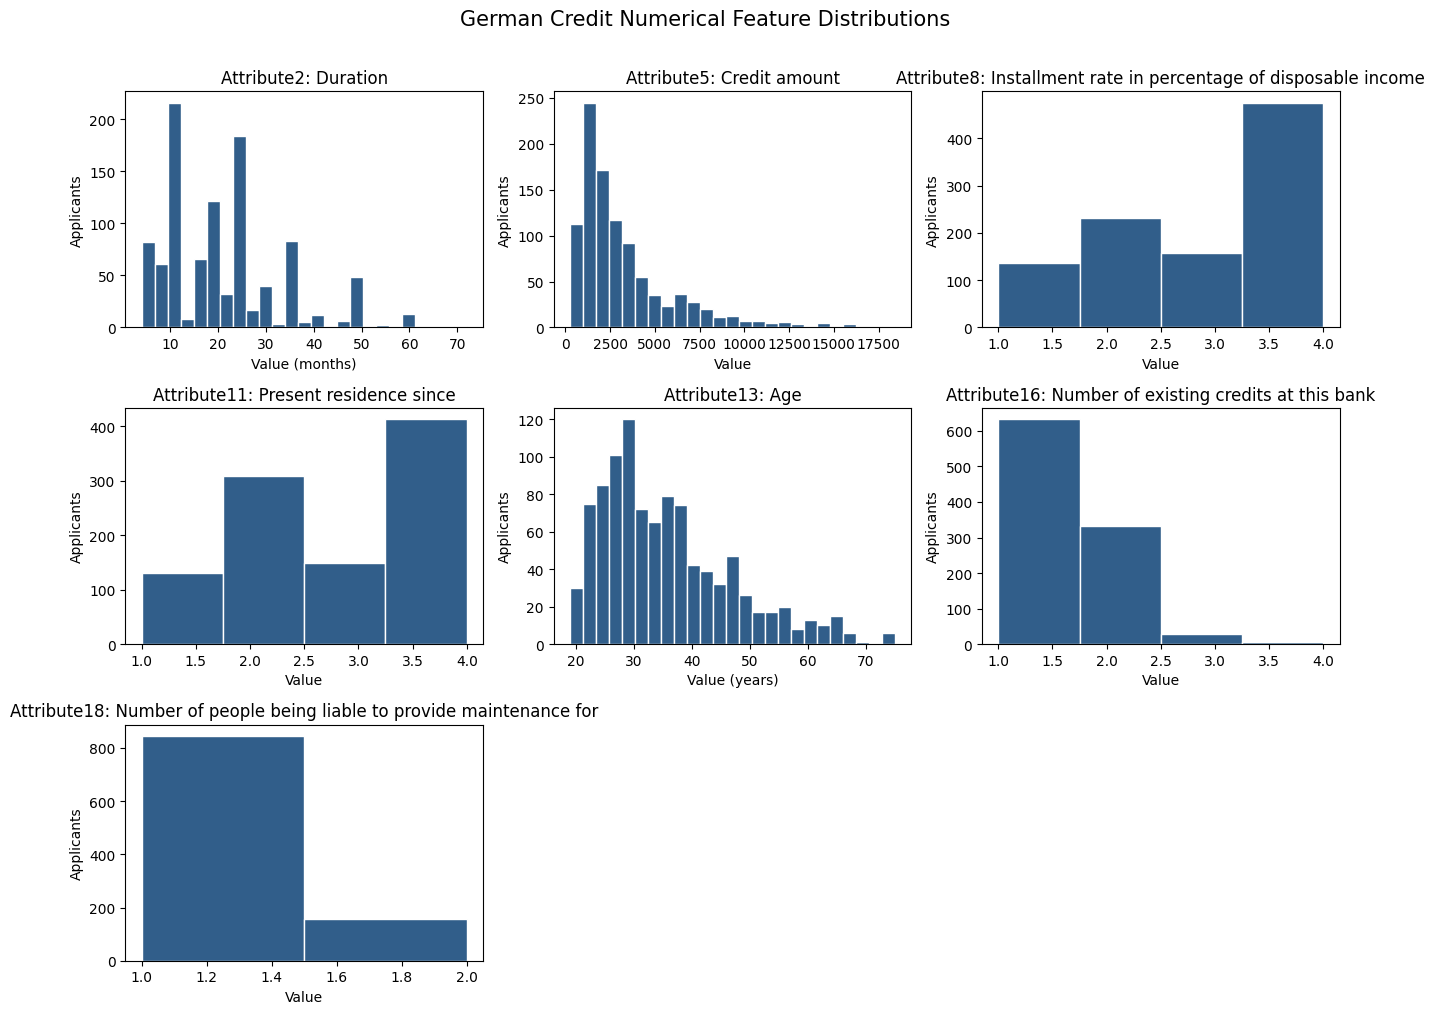

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.ravel()
for axis, feature in zip(axes, numerical_features):
    axis.hist(X[feature], bins=min(25, int(X[feature].nunique())), color="#315E8A", edgecolor="white")
    description = variable_lookup.loc[feature, "description"]
    units = variable_lookup.loc[feature, "units"]
    axis.set_title(f"{feature}: {description}")
    axis.set_xlabel(f"Value{f' ({units})' if pd.notna(units) else ''}")
    axis.set_ylabel("Applicants")
for axis in axes[len(numerical_features):]:
    axis.set_visible(False)
fig.suptitle("German Credit Numerical Feature Distributions", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "german_credit_numerical_distributions.png", dpi=180, bbox_inches="tight")
plt.show()


## 12. Selected relationships with the target

Duration, credit amount, and age are examined against the original good/bad target because they are interpretable, important credit-domain variables. The comparisons are descriptive and do not imply causality.


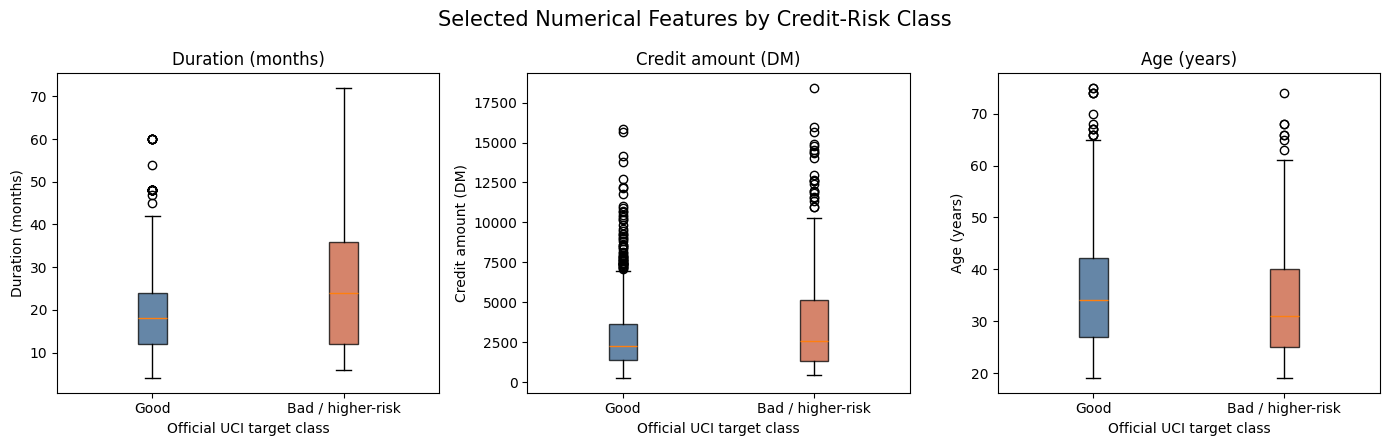

Attribute2                              Attribute5                       \
           count       mean median        std      count         mean  median   
class                                                                           
1            700  19.207143   18.0  11.079564        700  2985.457143  2244.0   
2            300  24.860000   24.0  13.282639        300  3938.126667  2574.5   

                   Attribute13                               
               std       count       mean median        std  
class                                                        
1      2401.472278         700  36.224286   34.0  11.381145  
2      3535.818955         300  33.963333   31.0  11.222379

In [12]:
relationship_features = ["Attribute2", "Attribute5", "Attribute13"]
relationship_labels = ["Duration (months)", "Credit amount (DM)", "Age (years)"]
plot_frame = raw_df.copy()
plot_frame["credit_risk_label"] = plot_frame[TARGET].map({1: "Good", 2: "Bad / higher-risk"})

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for axis, feature, label in zip(axes, relationship_features, relationship_labels):
    groups = [
        plot_frame.loc[plot_frame[TARGET].eq(target_value), feature]
        for target_value in (1, 2)
    ]
    box = axis.boxplot(groups, tick_labels=["Good", "Bad / higher-risk"], patch_artist=True)
    for patch, color in zip(box["boxes"], ["#315E8A", "#C75B39"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axis.set_title(label)
    axis.set_xlabel("Official UCI target class")
    axis.set_ylabel(label)
fig.suptitle("Selected Numerical Features by Credit-Risk Class", fontsize=15)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "german_credit_selected_features_by_target.png", dpi=180, bbox_inches="tight")
plt.show()

grouped_summary = plot_frame.groupby(TARGET)[relationship_features].agg(["count", "mean", "median", "std"])
display(grouped_summary)


## 13. Potential sensitive/proxy attributes and leakage review

These variables are retained and documented, not automatically removed. Their later use requires an explicit methodological decision. This is an exploratory identification, not a legal determination.


In [13]:
sensitive_proxy_audit = pd.DataFrame([
    {"feature": "Attribute9", "description": "Personal status and sex", "reason_for_review": "Directly combines sex/gender with marital/personal status"},
    {"feature": "Attribute13", "description": "Age in years", "reason_for_review": "Direct age attribute"},
    {"feature": "Attribute7", "description": "Present employment since", "reason_for_review": "Employment history may act as a socioeconomic proxy"},
    {"feature": "Attribute15", "description": "Housing", "reason_for_review": "Housing tenure may act as a socioeconomic proxy"},
    {"feature": "Attribute17", "description": "Job", "reason_for_review": "Occupation/employment status may act as a socioeconomic proxy"},
    {"feature": "Attribute20", "description": "Foreign worker", "reason_for_review": "Nationality/migration-related indicator or proxy"},
    {"feature": "Attribute12", "description": "Property", "reason_for_review": "Asset ownership may act as a socioeconomic proxy"},
    {"feature": "Attribute6", "description": "Savings account/bonds", "reason_for_review": "Wealth-related proxy"},
])
display(sensitive_proxy_audit)

leakage_audit = pd.DataFrame([
    {"item": "Target included among predictors", "finding": TARGET in X.columns, "assessment": "No: target is held separately during exploration."},
    {"item": "Obvious post-outcome field", "finding": False, "assessment": "None identified from official descriptions; confirm temporal availability before modelling."},
    {"item": "Credit history", "finding": True, "assessment": "Predictive historical information, not obvious leakage, provided it predates the decision."},
    {"item": "Existing checking/savings status", "finding": True, "assessment": "Potentially contemporaneous; document decision-time availability in Stage 02."},
])
display(leakage_audit)


,feature,description,reason_for_review
0,Attribute9,Personal status and sex,Directly combines sex/gender with marital/pers...
1,Attribute13,Age in years,Direct age attribute
2,Attribute7,Present employment since,Employment history may act as a socioeconomic ...
3,Attribute15,Housing,Housing tenure may act as a socioeconomic proxy
4,Attribute17,Job,Occupation/employment status may act as a soci...
5,Attribute20,Foreign worker,Nationality/migration-related indicator or proxy
6,Attribute12,Property,Asset ownership may act as a socioeconomic proxy
7,Attribute6,Savings account/bonds,Wealth-related proxy


,item,finding,assessment
0,Target included among predictors,False,No: target is held separately during exploration.
1,Obvious post-outcome field,False,None identified from official descriptions; co...
2,Credit history,True,"Predictive historical information, not obvious..."
3,Existing checking/savings status,True,Potentially contemporaneous; document decision...


## 14. Dataset limitations and Stage 01 interpretation

- The dataset is small (1,000 observations), so later validation and XAI stability designs should not be copied automatically from Home Credit.
- The target is moderately imbalanced: 70% good and 30% bad/higher-risk, not an extreme rare-event setting.
- Data originate from 1994 or earlier and monetary amounts are denominated in DM; population, policy, and economic relevance to current UK lending are limited.
- Category labels are symbolic A-codes and require the official codebook for interpretation.
- Attribute9 combines sex with personal status, making their effects inseparable without additional assumptions.
- “Unknown/no account/property” codes are observed categories, not native nulls; later treatment must be explicit.
- UCI provides no recommended split. Any later evaluation protocol requires approval and must account for the small sample.
- The official asymmetric cost matrix states that classifying a bad customer as good is costlier than the reverse; later model evaluation should decide explicitly whether and how to use it.
- No causal, fairness, or legal conclusions are made at this exploratory stage.


## 15. Machine-readable dataset summary and provenance


In [14]:
dataset_summary = {
    "dataset_name": DATASET_NAME,
    "uci_dataset_id": UCI_DATASET_ID,
    "raw_rows": int(len(raw_df)),
    "raw_predictors": int(X.shape[1]),
    "target_column": TARGET,
    "target_values": sorted(int(value) for value in y.unique()),
    "target_meanings": {"1": "Good credit risk", "2": "Bad credit risk / higher-risk class"},
    "class_counts": {str(int(key)): int(value) for key, value in target_counts.items()},
    "class_percentages": {str(int(key)): float(value) for key, value in target_percentages.items()},
    "numerical_features": len(numerical_features),
    "categorical_or_binary_features": len(categorical_features),
    "total_missing_values": int(missing_counts.sum()),
    "duplicate_complete_rows": duplicate_rows,
    "duplicate_predictor_profiles": duplicate_feature_rows,
    "feature_names_unique": bool(pd.Index(feature_names).is_unique),
    "stage": "01_data_exploration",
    "modelling_performed": False,
    "train_test_split_created": False,
    "preprocessing_fitted": False,
    "model_trained": False,
}
with (ARTIFACTS_DIR / "dataset_summary.json").open("w", encoding="utf-8") as file:
    json.dump(dataset_summary, file, indent=2)
display(pd.Series(dataset_summary, name="value").to_frame())


,value
dataset_name,Statlog (German Credit Data)
uci_dataset_id,144
raw_rows,1000
raw_predictors,20
target_column,class
target_values,"[1, 2]"
target_meanings,"{'1': 'Good credit risk', '2': 'Bad credit ris..."
class_counts,"{'1': 700, '2': 300}"
class_percentages,"{'1': 70.0, '2': 30.0}"
numerical_features,7


## 16. Quality and reproducibility checks

These assertions establish raw-data invariants only. They do not validate or fit any modelling pipeline.


In [15]:
assert len(raw_df) == EXPECTED_ROWS
assert X.shape == (EXPECTED_ROWS, EXPECTED_FEATURES)
assert len(y) == len(X)
assert set(y.dropna().unique()) == EXPECTED_TARGET_VALUES
assert y.isna().sum() == 0
assert pd.Index(feature_names).is_unique
assert TARGET not in X.columns
assert len(numerical_features) == 7
assert len(categorical_features) == 13
assert int(missing_counts.sum()) == 0
assert duplicate_rows >= 0
assert not any(path.name.startswith(("train_indices", "test_indices", "model", "preprocessor")) for path in ARTIFACTS_DIR.iterdir())

print(f"Raw row count verified: {len(raw_df)}")
print(f"Raw feature count verified: {X.shape[1]}")
print(f"Target row alignment verified: {len(y) == len(X)}")
print(f"Observed target values verified: {sorted(y.unique())}")
print(f"Duplicate count known: {duplicate_rows}")
print(f"Missingness quantified: {int(missing_counts.sum())} native missing values")
print(f"Feature names unique: {pd.Index(feature_names).is_unique}")
print("Modelling performed: False")
print("Train/test split created: False")
print("Preprocessing fitted: False")
print("Model trained: False")
print("Stage 01 quality checks passed.")


Raw row count verified: 1000
Raw feature count verified: 20
Target row alignment verified: True
Observed target values verified: [np.int64(1), np.int64(2)]
Duplicate count known: 0
Missingness quantified: 0 native missing values
Feature names unique: True
Modelling performed: False
Train/test split created: False
Preprocessing fitted: False
Model trained: False
Stage 01 quality checks passed.


## 17. Decisions requiring approval before Stage 02

Before preprocessing or model design, approve decisions on:

1. Whether the positive modelling class should be the official bad/higher-risk class (original value 2) and how its encoding will be documented.
2. Whether potentially sensitive/proxy variables—especially Attribute9, Attribute13, and Attribute20—will be included, excluded, or handled through a defined comparison/sensitivity analysis.
3. How special categories such as “unknown/no account/property” will be represented without treating them as ordinary missing values.
4. The small-sample validation strategy and whether the official asymmetric cost matrix should inform evaluation.
5. How categorical A-codes will be renamed/mapped for interpretability while preserving raw provenance.
6. Whether candidate decision-time variables have adequate temporal availability and no leakage risk.

**Stop:** no Stage 02 work is performed in this notebook.
